# Wavelength-normalized MRG compositing

Method follows Li et al. (2026), doi:10.1029/2025JD046056.

Straight-line script: load -> KF filter -> find events -> measure L ->
check whether normalization helps -> composite on the normalized axis.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import easyclimate as ecl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

c:\Users\norna\anaconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## SETTINGS


In [2]:
NCFILE = r"C:\Users\norna\Downloads\olr.cbo-1deg.day.anom_2.nc"

LON_DATA   = (20, 160)   # WIDE data window: gives the +/-L stencil room and
                         # lets the wavelet actually see a full wavelength
LON_CENTER = (60, 100)   # where we look for wave centres (the region of interest)
LAT_DATA   = (15, -15)

# MRG OLR is ANTISYMMETRIC about the equator (node ON the equator), so we
# centre on a north-minus-south dipole index, NOT on a band straddling 0.
BAND_N = (5, 15)
BAND_S = (-15, -5)

THRESHOLD  = 1.0         # sigma of the activity index
MIN_SEP    = 5           # days between events
REFINE_WIN = 3           # +/- days to shift day 0 onto deepest convection
ACT_BOX    = (60, 100, -10, 10)   # activity index box: lon_w, lon_e, lat_s, lat_n

L_BOUNDS = (8.0, 50.0)   # half-wavelength search range, deg. Keep the upper end
                         # GENEROUS: it caps the wavelet scale search, so a tight
                         # bound silently pins long waves to the bound instead of
                         # rejecting them, which fakes a narrow L distribution.
N_X      = 81
X_MAX    = 1.0           # composite spans -L .. +L
LAGS     = [-2, -1, 0, 1, 2]
FLANK    = 0.35          # |x| > this is where cancellation bites
SN_MRG   = 0.5           # only used to REPORT how antisymmetric the events are;
                         # events are not filtered on it
SUBSET   = "all"         # composite every event, as in Li et al. ("mrg"/"td"
                         # available if you ever want the split)
ANTISYM_PLOT = True      # also plot the antisymmetric component of the composite

DOG2_FOURIER = 2.0 * np.pi / np.sqrt(2.5)     # = 3.973835, Torrence & Compo T1

## 1. LOAD + KF FILTER FOR MRG


In [3]:
ds = xr.open_dataset(NCFILE, decode_times=False)
tv = ds["time"].values
ds = ds.isel(time=(tv >= 0) & (tv < 1e10))
ds = ds.assign_coords(time=pd.to_datetime(ds["time"].values, unit="h",
                                          origin="1800-01-01"))

data = (ds["olr"].sel(time=slice("1991-01-01", "2026-08-15"))
        .sel(lat=slice(*LAT_DATA))
        .interpolate_na(dim="time", method="linear")
        .ffill(dim="time").bfill(dim="time"))

mrg = ecl.filter.kf_filter.kf_filter_mrg_wave(
    data, steps_per_day=1, tMin=3, tMax=9.6,
    kMin=-10, kMax=-2, hMin=10, hMax=100)

da = mrg.sel(lon=slice(*LON_DATA), lat=slice(*LAT_DATA))
if da.lat.values[0] > da.lat.values[-1]:
    da = da.sortby("lat")
da = da.sel(time=da.time.dt.month.isin([6, 7, 8, 9]))     # JJAS

lons = da.lon.values.astype(float)
lats = da.lat.values.astype(float)
dlon = float(np.abs(np.diff(lons).mean()))

## 2. ANTISYMMETRIC CENTRING PROFILE  (this is the key fix)


mean over (-5, 5) of an antisymmetric wave is IDENTICALLY ZERO -- the two
hemispheric lobes cancel and you are left centring on noise. The dipole
N - S instead adds them, doubling the amplitude vs one hemisphere alone.


In [4]:
north = da.sel(lat=slice(*BAND_N)).mean(dim="lat")
south = da.sel(lat=slice(*BAND_S)).mean(dim="lat")
dipole = (north - south)                       # (time, lon), antisymmetric index
dip = dipole.values.astype(float)

cmask = (lons >= LON_CENTER[0]) & (lons <= LON_CENTER[1])
csub = np.where(cmask)[0]

## 3. ACTIVITY INDEX -> EVENTS, DAY 0 = DEEPEST CONVECTION


In [5]:
w, e, s, n = ACT_BOX
box = da.sel(lon=slice(w, e), lat=slice(s, n))
index = box.std(dim=["lat", "lon"])
index = (index - index.mean()) / index.std()

vals = index.values.astype(float)
times = pd.to_datetime(index.time.values)
peaks, _ = find_peaks(np.nan_to_num(vals, nan=-9e9),
                      height=THRESHOLD, distance=MIN_SEP)

# JJAS-only data leaves year-long gaps, so neighbouring indices can be a year
# apart. Refinement must not step across a gap or day 0 lands in another season.
day = times.values.astype("datetime64[D]").astype(np.int64)
seg = np.concatenate([[0], np.cumsum(np.diff(day) != 1)])

refined = []
for pi in peaks:
    j0, j1 = max(0, pi - REFINE_WIN), min(vals.size - 1, pi + REFINE_WIN)
    cand = [j for j in range(j0, j1 + 1) if seg[j] == seg[pi]]
    # deepest convection in the north lobe = most negative dipole
    refined.append(min(cand, key=lambda j: np.nanmin(dip[j][cmask])))
refined = np.asarray(refined, int)

ev = (pd.DataFrame({"date": times[refined],
                    "index_date": times[peaks],
                    "amplitude": vals[peaks],
                    "shift": refined - peaks})
      .drop_duplicates("date").sort_values("date").reset_index(drop=True))

ev_idx = np.searchsorted(times, ev["date"].values)     # row of each event in dip
sh = ev["shift"].values

print(f"{len(ev)} events (threshold {THRESHOLD} sigma)")
print(f"  day 0 moved for {np.mean(sh != 0)*100:.0f}% of them "
      f"(normal: even a clean signal moves ~75%)")
print(f"  saturated at +/-{REFINE_WIN} d for {np.mean(np.abs(sh) == REFINE_WIN)*100:.0f}% "
      f"  <-- THE DIAGNOSTIC. >20% means you are centring on noise.")
print(f"  mean |shift| {np.mean(np.abs(sh)):.2f} d")

161 events (threshold 1.0 sigma)
  day 0 moved for 78% of them (normal: even a clean signal moves ~75%)
  saturated at +/-3 d for 14%   <-- THE DIAGNOSTIC. >20% means you are centring on noise.
  mean |shift| 1.40 d


## 4. HALF-WAVELENGTH L PER EVENT  (Mexican hat / DOG m=2 wavelet)


In [6]:
def half_wavelength(profile, ci, method="wavelet"):
    """Half-wavelength in degrees at longitude index ci, or nan."""
    p = np.asarray(profile, float)
    if not np.any(np.isfinite(p)):
        return np.nan
    p = np.nan_to_num(p - 0.0)

    if method == "wavelet":
        scales = np.geomspace(2.0 * L_BOUNDS[0] / DOG2_FOURIER / dlon,
                              2.0 * L_BOUNDS[1] / DOG2_FOURIER / dlon, 200)
        t = (np.arange(p.size) - ci).astype(float)
        norm = 2.0 / (np.sqrt(3.0) * np.pi ** 0.25)
        power = np.empty(scales.size)
        for i, sc in enumerate(scales):
            u = t / sc
            psi = norm * (1.0 - u ** 2) * np.exp(-0.5 * u ** 2)
            power[i] = (np.sum(p * psi) / np.sqrt(sc)) ** 2
        k = int(np.argmax(power))
        if k == 0 or k == scales.size - 1:
            return np.nan          # peak is AT the search edge -> the true scale
                                   # lies outside L_BOUNDS. Reject, do not pin.
        L = 0.5 * DOG2_FOURIER * scales[k] * dlon
    else:
        # zero crossings either side of the centre. No mean removal: the
        # filtered field is already zero-mean, and subtracting a mean over a
        # non-integer number of cycles shifts the crossings and biases L.
        sgn = np.sign(p[ci])
        if sgn == 0:
            return np.nan
        r = next((k for k in range(ci + 1, p.size) if np.sign(p[k]) != sgn), None)
        l = next((k for k in range(ci - 1, -1, -1) if np.sign(p[k]) != sgn), None)
        if r is None or l is None:
            return np.nan
        L = (r - l) * dlon

    return L if L_BOUNDS[0] <= L <= L_BOUNDS[1] else np.nan

L_deg, lon_c = np.full(len(ev), np.nan), np.full(len(ev), np.nan)
L_zc = np.full(len(ev), np.nan)
sn = np.full(len(ev), np.nan)              # antisymmetry: |south lobe|/|north lobe|
pn, ps = north.values.astype(float), south.values.astype(float)
for j, it in enumerate(ev_idx):
    prof = dip[it]
    ci = int(csub[np.nanargmin(prof[cmask])])          # deepest convection
    lon_c[j] = lons[ci]
    L_deg[j] = half_wavelength(prof, ci, "wavelet")
    L_zc[j] = half_wavelength(prof, ci, "zerocross")
    # A true MRG wave is antisymmetric: the southern lobe mirrors the northern
    # one, so S/N ~ 1. A TD-type disturbance sits at ~10N with nothing to the
    # south, so S/N ~ 0. This is the MRG vs MRG-TD discriminant.
    a_n = np.nanmax(np.abs(pn[it][cmask]))
    a_s = np.nanmax(np.abs(ps[it][cmask]))
    sn[j] = a_s / a_n if a_n > 0 else np.nan

ok = np.isfinite(L_deg)
Lbar = np.nanmean(L_deg[ok])
km = 111.195 * np.cos(np.deg2rad(10.0))               # at the lobe latitude
print(f"\nL measured for {ok.sum()}/{len(ev)} events")
print(f"  mean L {Lbar:.1f} deg  (full wavelength ~{2*Lbar*km:.0f} km)")
print(f"  std L  {np.nanstd(L_deg[ok]):.1f} deg    CV {np.nanstd(L_deg[ok])/Lbar:.2f}")
both = ok & np.isfinite(L_zc)
gap = abs(np.nanmean(L_deg[both]) - np.nanmean(L_zc[both])) / Lbar
print(f"  cross-check: wavelet {np.nanmean(L_deg[both]):.1f} vs "
      f"zerocross {np.nanmean(L_zc[both]):.1f} deg  ({100*gap:.0f}% apart)")
print("    zerocross is grid-quantized and runs ~5-8% high, so <10% is expected;"
      " >15% means the profiles are not clean single waves.")

# --- MRG-like or TD-like? --------------------------------------------------
# S/N ~ 1 : antisymmetric, a genuine MRG wave
# S/N ~ 0 : northern lobe only, a TD-type / monsoon-trough disturbance
mrg_like = ok & (sn >= SN_MRG)
td_like = ok & (sn < SN_MRG)
print(f"\nantisymmetry S/N = |south lobe| / |north lobe|")
print(f"  median S/N {np.nanmedian(sn[ok]):.2f}")
print(f"  MRG-like (S/N >= {SN_MRG}) : {mrg_like.sum()} events")
print(f"  TD-like  (S/N <  {SN_MRG}) : {td_like.sum()} events")
if mrg_like.sum():
    print(f"  mean L, MRG-like : {np.nanmean(L_deg[mrg_like]):.1f} deg"
          f"   CV {np.nanstd(L_deg[mrg_like])/np.nanmean(L_deg[mrg_like]):.2f}")
if td_like.sum():
    print(f"  mean L, TD-like  : {np.nanmean(L_deg[td_like]):.1f} deg"
          f"   CV {np.nanstd(L_deg[td_like])/np.nanmean(L_deg[td_like]):.2f}")
print("  If these two L means differ a lot, your CV is population MIXING,"
      " not within-type spread.")

# Everything below composites and tests only the chosen subset. This project is
# about MRG waves, so SUBSET = "mrg": TD-type events are excluded outright, not
# averaged in. Note L, CV and the gain are all re-measured on this subset.
use = {"all": ok, "mrg": mrg_like, "td": td_like}[SUBSET]
Lbar = np.nanmean(L_deg[use])
print(f"\ncompositing SUBSET = '{SUBSET}': {use.sum()} events, "
      f"mean L {Lbar:.1f} deg, CV {np.nanstd(L_deg[use])/Lbar:.2f}")


L measured for 137/161 events
  mean L 30.4 deg  (full wavelength ~6660 km)
  std L  7.7 deg    CV 0.25
  cross-check: wavelet 30.0 vs zerocross 32.8 deg  (9% apart)
    zerocross is grid-quantized and runs ~5-8% high, so <10% is expected; >15% means the profiles are not clean single waves.

antisymmetry S/N = |south lobe| / |north lobe|
  median S/N 0.35
  MRG-like (S/N >= 0.5) : 38 events
  TD-like  (S/N <  0.5) : 99 events
  mean L, MRG-like : 30.7 deg   CV 0.27
  mean L, TD-like  : 30.3 deg   CV 0.25
  If these two L means differ a lot, your CV is population MIXING, not within-type spread.

compositing SUBSET = 'all': 137 events, mean L 30.4 deg, CV 0.25


## 5. DOES NORMALIZATION HELP?

centred-in-degrees vs centred-AND-scaled. Both are centred, so the only
difference is the scaling -- that is the fair test.



--- normalization check ---
  events kept after edge guard : 135/161  <-- if this is much below 161, widen LON_DATA or lower X_MAX
  centred in degrees : 64% of ceiling
  normalized by L    : 73% of ceiling
  gain               : 1.14x
  VERDICT: marginal - show both composites


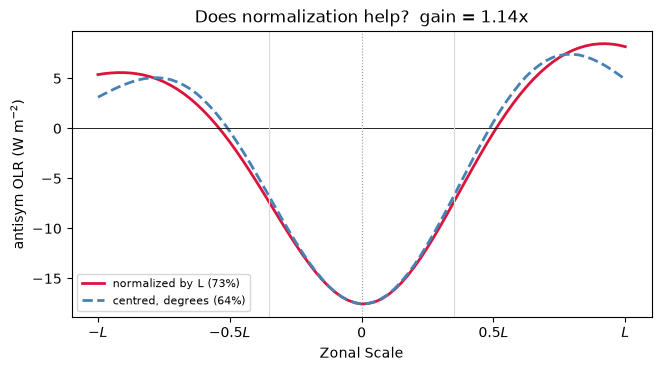

In [7]:
x = np.linspace(-X_MAX, X_MAX, N_X)
d_grid = x * Lbar                       # same axis, but in fixed degrees

st_deg = np.full((len(ev), N_X), np.nan)
st_nrm = np.full((len(ev), N_X), np.nan)
own = []
for j, it in enumerate(ev_idx):
    if not ok[j]:
        continue
    prof, c, L = dip[it], lon_c[j], L_deg[j]
    g = np.isfinite(prof)
    for tgt, store in ((c + d_grid, st_deg), (c + x * L, st_nrm)):
        if tgt[0] < lons.min() or tgt[-1] > lons.max():
            continue                    # stencil off the domain edge
        store[j] = np.interp(tgt, lons[g], prof[g])
    if np.isfinite(st_nrm[j]).all():
        own.append(np.nanmax(np.abs(st_nrm[j][np.abs(x) > FLANK])))

flank = np.abs(x) > FLANK
p_deg, p_nrm = np.nanmean(st_deg, axis=0), np.nanmean(st_nrm, axis=0)
ceil = np.mean(own)                     # each event's own flank amplitude
coh_deg = np.nanmax(np.abs(p_deg[flank])) / ceil
coh_nrm = np.nanmax(np.abs(p_nrm[flank])) / ceil
gain = coh_nrm / coh_deg

n_kept = int(np.isfinite(st_nrm[:, 0]).sum())
print(f"\n--- normalization check ---")
print(f"  events kept after edge guard : {n_kept}/{len(ev)}"
      f"  <-- if this is much below {len(ev)}, widen LON_DATA or lower X_MAX")
print(f"  centred in degrees : {100*coh_deg:.0f}% of ceiling")
print(f"  normalized by L    : {100*coh_nrm:.0f}% of ceiling")
print(f"  gain               : {gain:.2f}x")
print("  VERDICT:", "normalization is worth it" if gain > 1.3 else
      "marginal - show both composites" if gain > 1.1 else
      "not needed; centring alone is enough")

fig, ax = plt.subplots(figsize=(6.5, 3.6), constrained_layout=True)
ax.plot(x, p_nrm, color="crimson", lw=2, label=f"normalized by L ({100*coh_nrm:.0f}%)")
ax.plot(x, p_deg, color="steelblue", lw=2, ls="--",
        label=f"centred, degrees ({100*coh_deg:.0f}%)")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="0.6", lw=0.8, ls=":")
for v in (-FLANK, FLANK):
    ax.axvline(v, color="0.85", lw=0.8)
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_xticklabels(["$-L$", "$-0.5L$", "0", "$0.5L$", "$L$"])
ax.set_xlabel("Zonal Scale"); ax.set_ylabel("antisym OLR (W m$^{-2}$)")
ax.set_title(f"Does normalization help?  gain = {gain:.2f}x")
ax.legend(fontsize=8)
plt.show()

## 6. THE COMPOSITE, lat-lon on the normalized axis



composite S/N (south lobe / north lobe) = 0.26
  ~1.0 = cleanly antisymmetric MRG;  ~0.2 = northern lobe dominates.


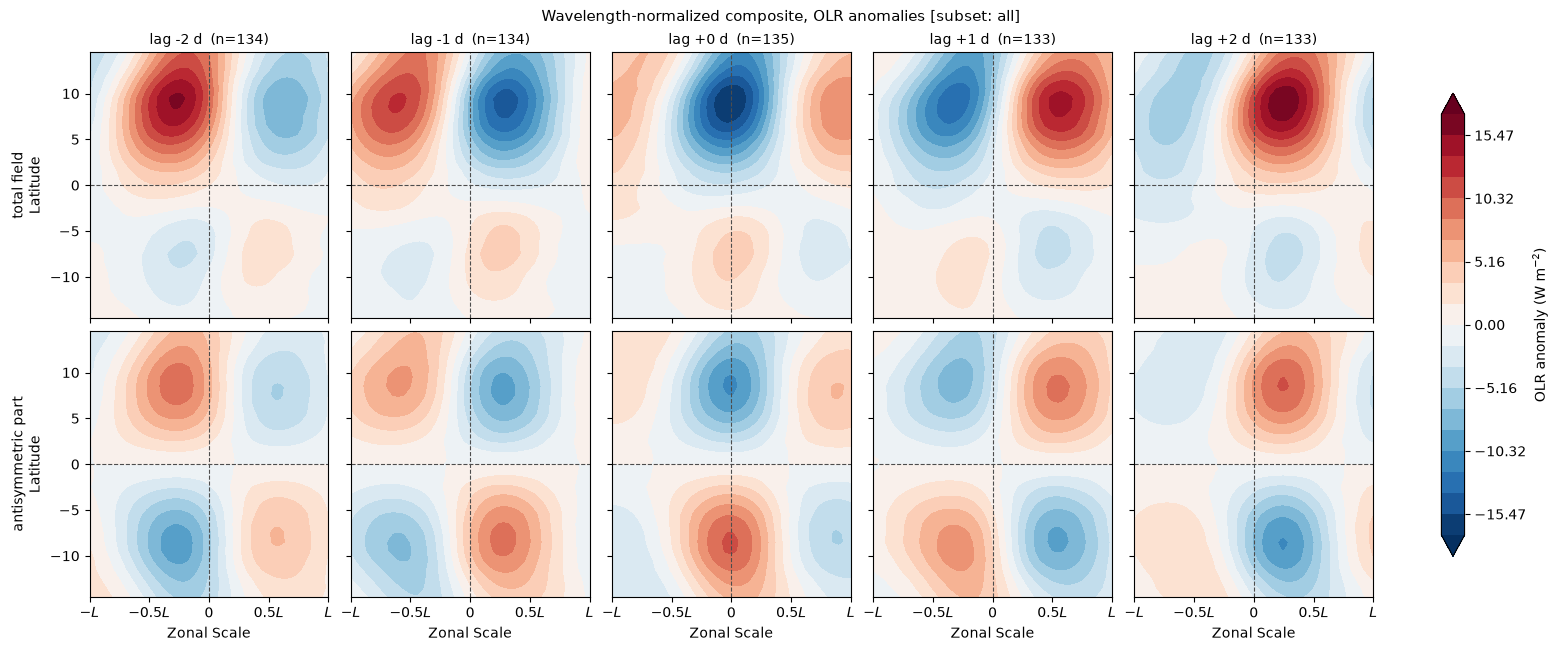

In [8]:
use = {"all": ok, "mrg": mrg_like, "td": td_like}[SUBSET]
comp = np.full((len(LAGS), lats.size, N_X), np.nan)
nlag = np.zeros(len(LAGS), int)

for i, lag in enumerate(LAGS):
    stack = np.full((len(ev), lats.size, N_X), np.nan)
    for j, it in enumerate(ev_idx):
        k = it + lag
        if not use[j] or k < 0 or k >= times.size or seg[k] != seg[it]:
            continue
        tgt = lon_c[j] + x * L_deg[j]
        if tgt[0] < lons.min() or tgt[-1] > lons.max():
            continue
        fld = da.isel(time=k).transpose("lat", "lon").values.astype(float)
        for m in range(lats.size):
            row = fld[m]
            g = np.isfinite(row)
            if g.sum() > 1:
                stack[j, m] = np.interp(tgt, lons[g], row[g])
    comp[i] = np.nanmean(stack, axis=0)
    nlag[i] = int(np.isfinite(stack[:, 0, 0]).sum())

# The antisymmetric part IS the MRG signal; plotting it next to the total field
# shows how much of the composite is the wave and how much is other structure
# sharing the same k-omega band.
comp_anti = 0.5 * (comp - comp[:, ::-1, :])
print(f"\ncomposite S/N (south lobe / north lobe) = "
      f"{np.nanmax(np.abs(comp[:, lats <= -5, :]))/np.nanmax(np.abs(comp[:, lats >= 5, :])):.2f}")
print("  ~1.0 = cleanly antisymmetric MRG;  ~0.2 = northern lobe dominates.")

rows = [("total field", comp)] + ([("antisymmetric part", comp_anti)]
                                  if ANTISYM_PLOT else [])
vmax = np.nanmax(np.abs(comp))
levels = np.linspace(-vmax, vmax, 21)
fig, axes = plt.subplots(len(rows), len(LAGS),
                         figsize=(3.1*len(LAGS), 3.2*len(rows)),
                         sharex=True, sharey=True, squeeze=False,
                         constrained_layout=True)
for r, (rname, arr) in enumerate(rows):
    for i in range(len(LAGS)):
        ax = axes[r][i]
        cf = ax.contourf(x, lats, arr[i], levels=levels, cmap="RdBu_r",
                         extend="both")
        ax.axvline(0, color="0.3", lw=0.8, ls="--")
        ax.axhline(0, color="0.3", lw=0.8, ls="--")
        if r == 0:
            ax.set_title(f"lag {LAGS[i]:+d} d  (n={nlag[i]})", fontsize=10)
        ax.set_xticks([-1, -0.5, 0, 0.5, 1])
        ax.set_xticklabels(["$-L$", "$-0.5L$", "0", "$0.5L$", "$L$"])
        if r == len(rows) - 1:
            ax.set_xlabel("Zonal Scale")
    axes[r][0].set_ylabel(f"{rname}\nLatitude")
fig.colorbar(cf, ax=axes, label="OLR anomaly (W m$^{-2}$)", shrink=0.85)
fig.suptitle(f"Wavelength-normalized composite, OLR anomalies "
             f"[subset: {SUBSET}]", fontsize=11)
plt.show()